Loaded samples: (12874, 1152)
Methods present: ['PointMAE_pretrain_Airplane' 'PointMAE_pretrain_Default'
 'PointMAE_pretrain_centered' 'PointMAE_pretrain_centered_Extruded'
 'PointMAE_pretrain_default_Extruded' 'PointMAE_pretrain_normalized'
 'PointMAE_pretrain_normalized_Extruded']


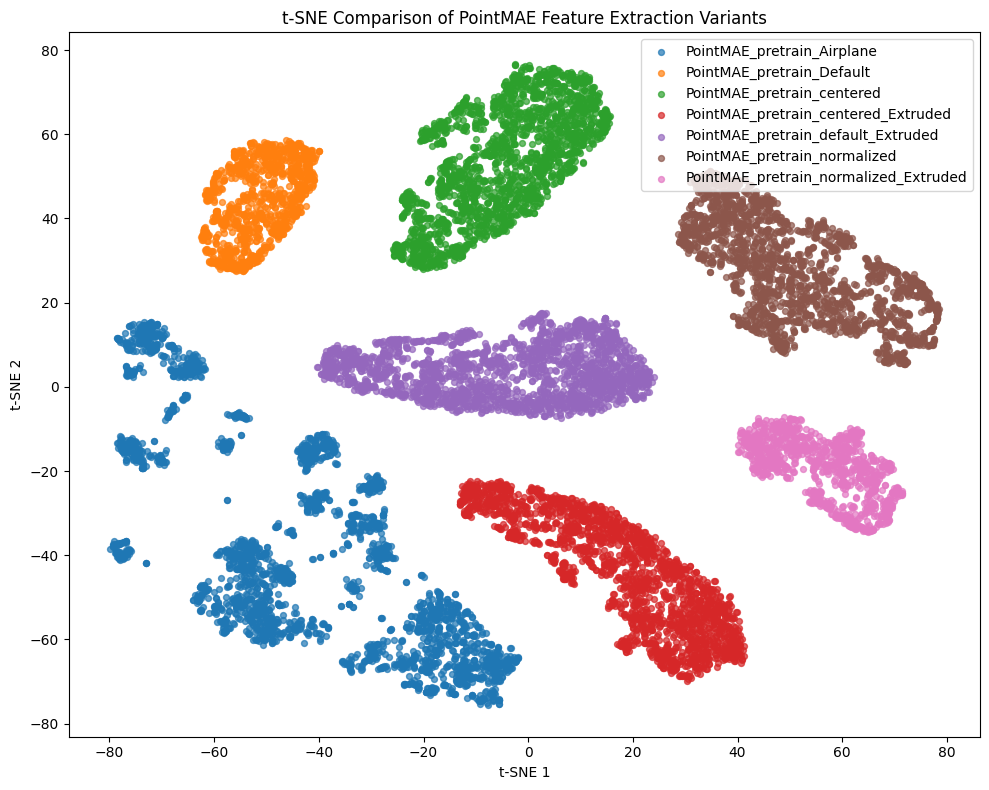

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# Base folder where your extracted features are stored
from pathlib import Path

BASE_DIR = Path.cwd() / "extracted_features"

# List only the 6 selected feature folders
selected_folders = [
    "PointMAE_pretrain_centered",
    "PointMAE_pretrain_centered_Extruded",
    "PointMAE_pretrain_Default",
    "PointMAE_pretrain_default_Extruded",
    "PointMAE_pretrain_normalized",
    "PointMAE_pretrain_normalized_Extruded",
    "PointMAE_pretrain_Airplane"
]

dfs = []

for folder in selected_folders:
    folder_path = os.path.join(BASE_DIR, folder)
    # Expect exactly one CSV inside each folder
    csvs = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    if len(csvs) == 0:
        print(f"⚠️ No CSV found in {folder_path}")
        continue
    
    csv_path = os.path.join(folder_path, csvs[0])
    df = pd.read_csv(csv_path)

    # Add a column indicating which feature set these belong to
    df["method"] = folder

    dfs.append(df)

# Combine all feature sets
ALL = pd.concat(dfs, ignore_index=True)

# Extract feature columns only
feature_cols = [c for c in ALL.columns if c.startswith("feat_")]
X = ALL[feature_cols].values
methods = ALL["method"].values

print("Loaded samples:", X.shape)
print("Methods present:", np.unique(methods))

# ---- Run t-SNE ----
tsne = TSNE(n_components=2, perplexity=40, random_state=0)
X_2d = tsne.fit_transform(X)

# ---- Plot ----
plt.figure(figsize=(10, 8))
unique_methods = np.unique(methods)

for m in unique_methods:
    idx = methods == m
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=18, alpha=0.7, label=m)

plt.legend(loc="best")
plt.title("t-SNE Comparison of PointMAE Feature Extraction Variants")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


Loaded samples: (12874, 1024)
Methods present: ['cls_model_35_Airplane' 'cls_model_35_Default' 'cls_model_35_centered'
 'cls_model_35_centered_Extruded' 'cls_model_35_default_Extruded'
 'cls_model_35_normalized' 'cls_model_35_normalized_Extruded']


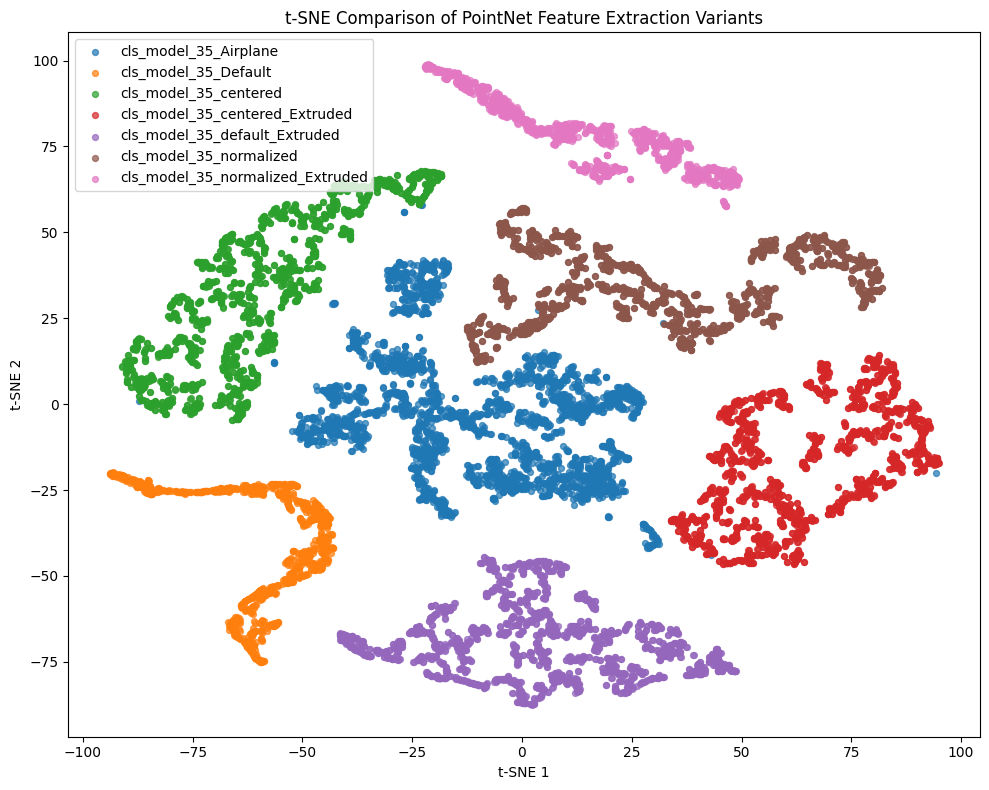

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

# Base folder where your extracted features are stored
from pathlib import Path

BASE_DIR = Path.cwd() / "extracted_features"

# List only the 6 selected feature folders
selected_folders = [
    "cls_model_35_centered",
    "cls_model_35_centered_Extruded",
    "cls_model_35_Default",
    "cls_model_35_default_Extruded",
    "cls_model_35_normalized",
    "cls_model_35_normalized_Extruded",
    "cls_model_35_Airplane"
]

dfs = []

for folder in selected_folders:
    folder_path = os.path.join(BASE_DIR, folder)
    # Expect exactly one CSV inside each folder
    csvs = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    if len(csvs) == 0:
        print(f"⚠️ No CSV found in {folder_path}")
        continue
    
    csv_path = os.path.join(folder_path, csvs[0])
    df = pd.read_csv(csv_path)

    # Add a column indicating which feature set these belong to
    df["method"] = folder

    dfs.append(df)

# Combine all feature sets
ALL = pd.concat(dfs, ignore_index=True)

# Extract feature columns only
feature_cols = [c for c in ALL.columns if c.startswith("feat_")]
X = ALL[feature_cols].values
methods = ALL["method"].values

print("Loaded samples:", X.shape)
print("Methods present:", np.unique(methods))

# ---- Run t-SNE ----
tsne = TSNE(n_components=2, perplexity=40, random_state=0)
X_2d = tsne.fit_transform(X)

# ---- Plot ----
plt.figure(figsize=(10, 8))
unique_methods = np.unique(methods)

for m in unique_methods:
    idx = methods == m
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=18, alpha=0.7, label=m)

plt.legend(loc="best")
plt.title("t-SNE Comparison of PointNet Feature Extraction Variants")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()
